Accuracy: 85.60%

              precision    recall  f1-score   support

    negativa       0.88      0.84      0.86       516
    positiva       0.84      0.87      0.85       484

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



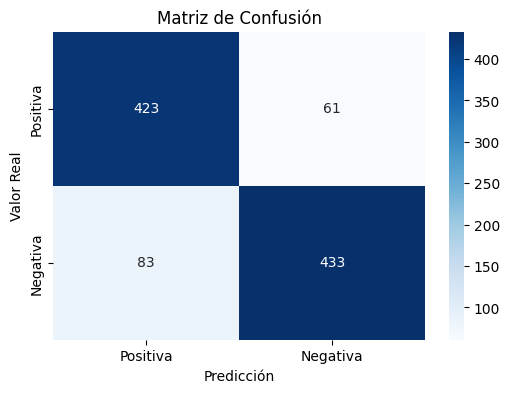


--- EJEMPLOS DE CLASIFICACIÓN ---
[Bien clasificado] Reseña: 'I absolutely loved this movie, the acting was brilliant and the story was captivating.' -> Predicción: POSITIVA
[Falso Negativo] Reseña: 'It's not as bad as people say, I actually enjoyed parts of it.' -> Predicción: POSITIVA
[Ambiguo] Reseña: 'The visuals were stunning but the plot was completely boring, I don't know if I recommend it.' -> Predicción: NEGATIVA


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Carga de datos de IMDB y selección de muestra
dataset = load_dataset("imdb", split="train")
df = pd.DataFrame(dataset)

# Muestra aleatoria de 5000 reseñas para balancear el dataset
df = df.sample(5000, random_state=42)

# Asignación de etiquetas
df['sentimiento'] = df['label'].apply(lambda x: 'positiva' if x == 1 else 'negativa')
df['review_text'] = df['text']

# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(df['review_text'], df['sentimiento'], test_size=0.2, random_state=42)

# Vectorización de texto mediante TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Entrenamiento del modelo (Regresión Logística)
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_tfidf, y_train)

# Evaluación y métricas
predicciones = modelo.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, predicciones)

print(f"Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, predicciones))

# Matriz de Confusión
cm = confusion_matrix(y_test, predicciones, labels=['positiva', 'negativa'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positiva', 'Negativa'], yticklabels=['Positiva', 'Negativa'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Prueba con 3 ejemplos específicos
print("\n--- EJEMPLOS DE CLASIFICACIÓN ---")
ejemplos = [
    "I absolutely loved this movie, the acting was brilliant and the story was captivating.",
    "It's not as bad as people say, I actually enjoyed parts of it.",
    "The visuals were stunning but the plot was completely boring, I don't know if I recommend it."
]
ejemplos_tfidf = vectorizer.transform(ejemplos)
predicciones_ejemplos = modelo.predict(ejemplos_tfidf)

etiquetas = ["Bien clasificado", "Falso Negativo", "Ambiguo"]

for i, texto in enumerate(ejemplos):
    print(f"[{etiquetas[i]}] Reseña: '{texto}' -> Predicción: {predicciones_ejemplos[i].upper()}")